In [8]:
import torch
import torch.nn as nn

In [9]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/vae_gan_tanh')

In [10]:
device = torch.device("cpu")
# for nvidia gpu ( cuda backend )
if (torch.cuda.is_available()):
    device = torch.device("cuda")
  # mps for apple M GPU ( metal backend )
elif (torch.backends.mps.is_available()):
    device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [11]:
lr_g = 1e-3
lr_d = 1e-3
batch_size = 256
epochs = 100
alpha = 1
beta = 0.5

In [12]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

dataset_path = '../../data'


mnist_transform = transforms.Compose([
    transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(
    dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(dataset_path, transform=mnist_transform,
                     train=False, download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size, shuffle=False, **kwargs)

In [13]:
import sys
sys.path.append('../../')
from model import VAE, Discriminator

vae = VAE(encoder=nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
),
    decoder=nn.Sequential(
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, 784),
        nn.Tanh()
),
    mean=nn.Linear(256, 128),
    var=nn.Linear(256, 128)).to(device)
dis = Discriminator(
    nn.Sequential(
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 256),
        nn.ReLU(),
        nn.Linear(256, 1),
        nn.Sigmoid()
    )
).to(device)
vae_opt = torch.optim.Adam(vae.parameters(), lr=lr_g)
dis_opt = torch.optim.Adam(dis.parameters(), lr=lr_d)

VAE model initialized
Discriminator model initialized


In [14]:
print("Start training VAE GAN...")
vae.train()
dis.train()
BCE = nn.BCELoss().to(device)
MSE = nn.MSELoss(reduction="sum").to(device)
for epoch in range(epochs):
    overall_loss_gen = 0
    overall_loss_dis = 0
    overall_loss_fake = 0
    overall_loss_real = 0
    overall_loss_kl = 0
    overall_loss_rec = 0
    for i, (x, _) in enumerate(train_loader):
        batch_size = x.size(0)
        x = x.view(-1, 784).to(device)
        real_label = torch.ones(batch_size, 1).to(device)
        fake_label = torch.zeros(batch_size, 1).to(device)
        # Train Discriminator
        _, mean, log_var,_,x_hat = vae(x)
        dis_real = dis(x)
        dis_fake = dis(x_hat.detach())
        dis_loss_real = BCE(dis_real, real_label)
        dis_loss_fake = BCE(dis_fake, fake_label)
        dis_loss = dis_loss_real + dis_loss_fake
        overall_loss_dis += dis_loss.item()
        overall_loss_fake += dis_loss_fake.item()
        overall_loss_real += dis_loss_real.item()
        dis_opt.zero_grad()
        dis_loss.backward()
        dis_opt.step()
        # Train Generator
        dis_fake = dis(x_hat)
        gen_loss_fake = BCE(dis_fake, real_label)
        rec_loss = MSE(x_hat, x)
        overall_loss_rec += rec_loss.item()
        kl = -beta * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
        overall_loss_kl += kl.item()
        gen_loss = alpha * gen_loss_fake + rec_loss + kl
        overall_loss_gen += gen_loss.item()
        vae_opt.zero_grad()
        gen_loss.backward()
        vae_opt.step()
    writer.add_scalar('Loss/Generator', overall_loss_gen / (batch_size*i), epoch)
    writer.add_scalar('Loss/Dis', dis_loss / len(train_loader), epoch)
    writer.add_scalar('Loss/Real', dis_loss_real / len(train_loader), epoch)
    writer.add_scalar('Loss/Fake', dis_loss_fake / len(train_loader), epoch)
    writer.add_scalar('Loss/Rec', overall_loss_rec / (batch_size*i), epoch)
    writer.add_scalar('Loss/KL', overall_loss_kl / (batch_size*i), epoch)
    print('Epoch: ', epoch, '| generator loss: %.4f' % (overall_loss_gen / (batch_size*i)),
          '| discriminator loss: %.4f' % (overall_loss_dis / len(train_loader)))

Start training VAE GAN...
Epoch:  0 | generator loss: 138.6611 | discriminator loss: 0.2133
Epoch:  1 | generator loss: 126.1856 | discriminator loss: 0.0213
Epoch:  2 | generator loss: 112.5897 | discriminator loss: 0.0449
Epoch:  3 | generator loss: 101.1219 | discriminator loss: 0.0342
Epoch:  4 | generator loss: 96.2562 | discriminator loss: 0.0253
Epoch:  5 | generator loss: 93.7691 | discriminator loss: 0.0265
Epoch:  6 | generator loss: 91.6321 | discriminator loss: 0.0206
Epoch:  7 | generator loss: 90.3436 | discriminator loss: 0.0172
Epoch:  8 | generator loss: 89.2865 | discriminator loss: 0.0214
Epoch:  9 | generator loss: 88.5132 | discriminator loss: 0.0153
Epoch:  10 | generator loss: 87.7457 | discriminator loss: 0.0144
Epoch:  11 | generator loss: 86.8618 | discriminator loss: 0.0154
Epoch:  12 | generator loss: 86.0605 | discriminator loss: 0.0148
Epoch:  13 | generator loss: 85.4532 | discriminator loss: 0.0227
Epoch:  14 | generator loss: 84.9422 | discriminator los

In [15]:

vae.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)
        _, _, _, _, x_hat = vae(x)
        break

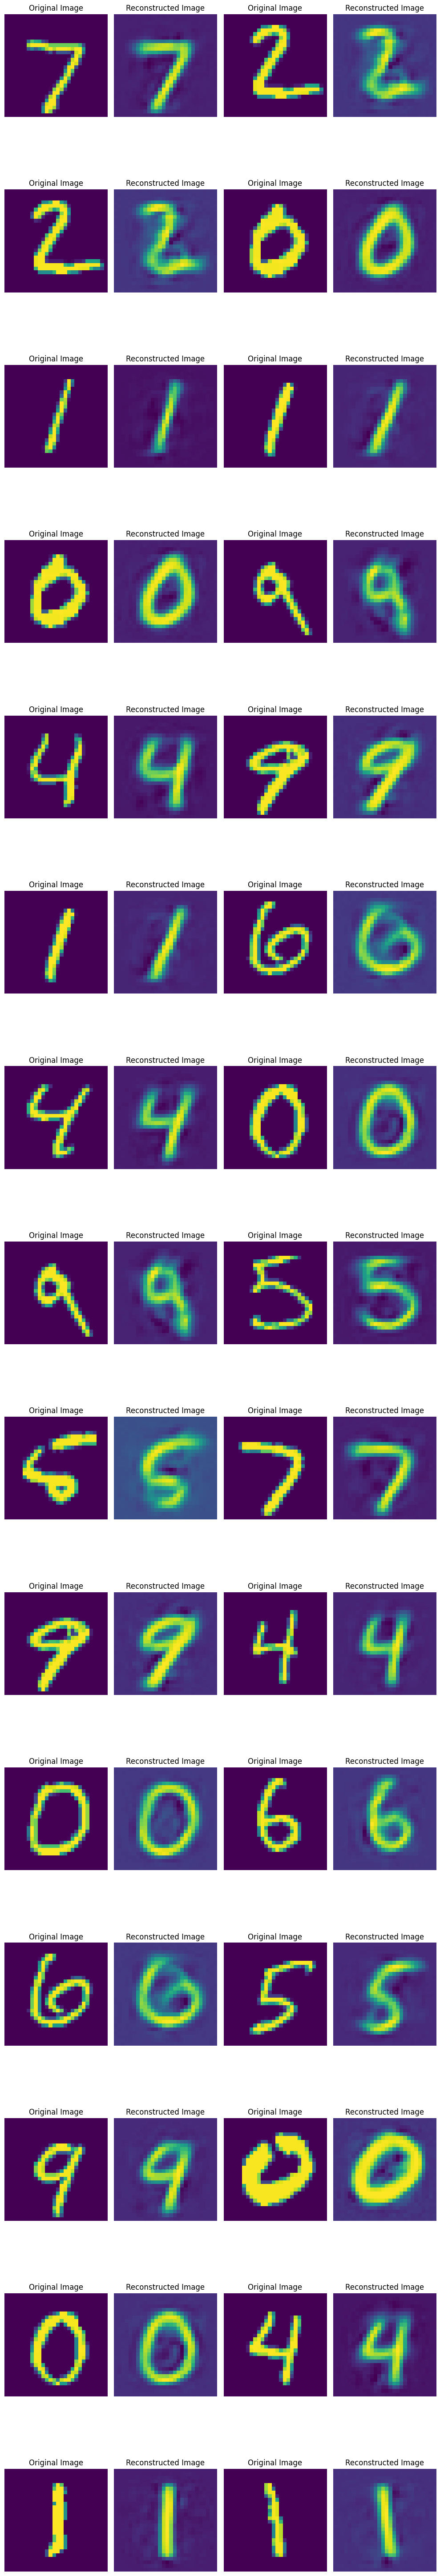

In [16]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=15, ncols=4, figsize=(10, 60))

for i in range(15):

    original_image = x[i].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[i].view(28, 28).cpu().numpy()

    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(reconstructed_image)
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')
    j = i*2+1
    original_image = x[j].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[j].view(28, 28).cpu().numpy()

    # Add your own images or modify as per your requirement
    axes[i, 2].imshow(original_image)
    axes[i, 2].set_title('Original Image')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(reconstructed_image)
    axes[i, 3].set_title('Reconstructed Image')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()